# Student Exam Performance Analysis

The goal of this project is to investigate the factors influencing students' academic performance and to build a predictive model that estimates exam scores based on demographic and behavioral characteristics. Specifically, our goal is to understand which factors most affect student exam performance and how accurately exam scores can be predicted using these features.

---

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Install scikit-learn if needed:
# pip install scikit-learn

# Library for splitting and preprocessing data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Libraries for modeling 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Libraries for evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

The dataset is loaded directly from Kaggle using the `kagglehub` adapter.
We display the first five rows to confirm the data loaded correctly and to get
a first look at the available columns and their values.

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "StudentPerformanceFactors.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "grandmaster07/student-exam-performance-dataset-analysis",
  file_path
)

print(df.shape)
df.head()

C:\Users\annak\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


-----

# Preprocessing

## Exploring the dataset

In [3]:
# Check dtypes of the columns and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [4]:
# Check the unique values in each categorical column
for col in df:
    if df[col].dtype == 'str':
        print(f"Unique values in column '{col}':")
        print(df[col].unique().tolist())
        print("========================================================")


Unique values in column 'Parental_Involvement':
['Low', 'Medium', 'High']
Unique values in column 'Access_to_Resources':
['High', 'Medium', 'Low']
Unique values in column 'Extracurricular_Activities':
['No', 'Yes']
Unique values in column 'Motivation_Level':
['Low', 'Medium', 'High']
Unique values in column 'Internet_Access':
['Yes', 'No']
Unique values in column 'Family_Income':
['Low', 'Medium', 'High']
Unique values in column 'Teacher_Quality':
['Medium', 'High', 'Low', nan]
Unique values in column 'School_Type':
['Public', 'Private']
Unique values in column 'Peer_Influence':
['Positive', 'Negative', 'Neutral']
Unique values in column 'Learning_Disabilities':
['No', 'Yes']
Unique values in column 'Parental_Education_Level':
['High School', 'College', 'Postgraduate', nan]
Unique values in column 'Distance_from_Home':
['Near', 'Moderate', 'Far', nan]
Unique values in column 'Gender':
['Male', 'Female']


In [5]:
# Numeric summary
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
# Count missing values in each column
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## Handling the Missing Values

`Teacher_Quality`, `Parental_Education_Level`, and `Distance_from_Home` appear to be the only three columns containing any missing values. Based on the dtype check, all three also so happen to contain categorical values, so to handle these missing values we will fill them with the modes (most frequent values) for their respective columns. 

In [7]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

# Verify that there are no more missing values
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## Encoding the Categorical Variables

Since machine learning models require numerical values, rather than strings, we need to encode the categorical columns accordingly. 

**Binary Columns**

Columns `Extracurricular_Activities`, `Internet_Access`, and `Learning_Disabilities` have only two unique values 'Yes' and 'No', which can be represented in binary format/mapped directly to 1 and 0 respectively.

**Ordinal Columns**

Columns `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, and `Teacher_Quality` have just three unique values ('Low', 'Medium', and 'High'), which have a natural order and therefore can be replaced with integers 0, 1, and 2 respectively.

Column `Parental_Education_Level` contains three unique values 'High School', 'College', and 'Postgraduate', which can be encoded as 0, 1, and 2 respectively as well.

Column `Distance_from_Home` contains three unique values 'Near', 'Moderate', and 'Far', which can also be encoded as 0, 1, and 2 respectively.

**Nominal Columns**

Finally, columns `School_Type` (Public vs Private), `Peer_Influence` (Positive vs Neutral vs Negative), and `Gender` (Male vs Female) have no natural order, therefore we cannot assign them with specific ordered numbers. Instead, we will apply One-Hot encoding using ```pd.get_dummies()```. `drop_first=True` removes one dummy per group to avoid the dummy variable trap (multicollinearity).

In [8]:
# NOTE: Only run this cell once to avoid re-encoding already encoded columns. If you need to re-run, please reload the original dataset first.

# Encode binary categorical variables
binary_mapping = {'Yes': 1, 'No': 0}
df['Extracurricular_Activities']    = df['Extracurricular_Activities'].map(binary_mapping)
df['Internet_Access']               = df['Internet_Access'].map(binary_mapping)
df['Learning_Disabilities']         = df['Learning_Disabilities'].map(binary_mapping)


# Encode ordinal categorical variables
levels_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Parental_Involvement'] = df['Parental_Involvement'].map(levels_mapping)
df['Access_to_Resources'] = df['Access_to_Resources'].map(levels_mapping)
df['Motivation_Level'] = df['Motivation_Level'].map(levels_mapping)
df['Family_Income'] = df['Family_Income'].map(levels_mapping)
df['Teacher_Quality'] = df['Teacher_Quality'].map(levels_mapping)

df['Parental_Education_Level'] = df['Parental_Education_Level'].map({
    'High School': 0,
    'College': 1,
    'Postgraduate': 2})

df['Distance_from_Home'] = df['Distance_from_Home'].map({
    'Near': 0,
    'Moderate': 1,
    'Far': 2})


# Encode nominal categorical variables using one-hot encoding
df = pd.get_dummies(df, columns=['School_Type', 'Peer_Influence', 'Gender'], drop_first=True)

In [9]:
# Check the dataframe info again to confirm changes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  Physical_Activity           6607 non-null   int64
 13  Learning_Disabilities       6607 non-null   int64
 14  Parental_Education_

## Dropping the Outliers

Outliers in the target variable (`Exam_Score`) can distort model training,
causing the model to skew its predictions toward extreme values.

We use the **IQR (Interquartile Range) method**:
- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 - Q1
- Any score below `Q1 - 1.5 x IQR` or above `Q3 + 1.5 x IQR` is flagged as an outlier

We visualise the distribution **before and after** removal using histograms and
boxplots so we can confirm the effect of the cleaning step on the data.

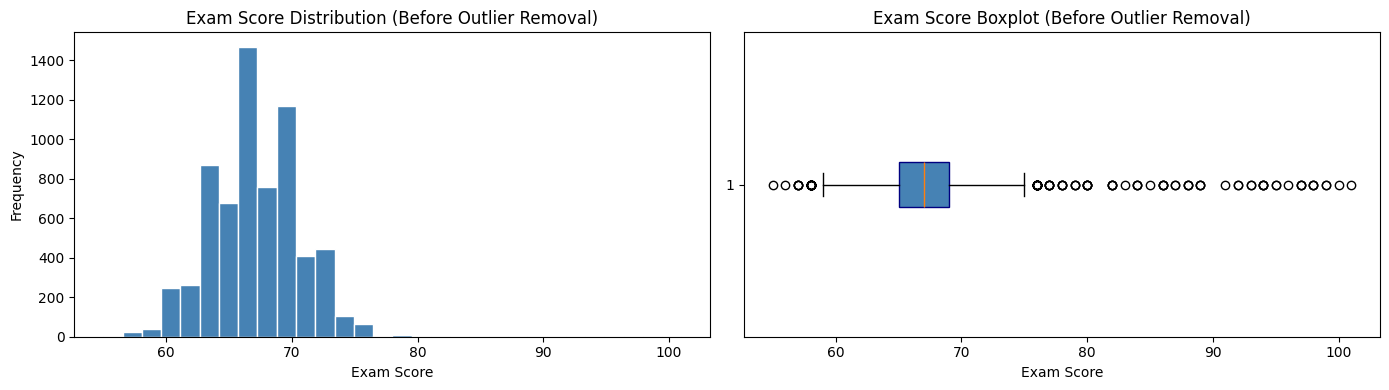

Rows before removal: 6607
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [10]:
# --- Distribution BEFORE outlier removal ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["Exam_Score"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Exam Score Distribution (Before Outlier Removal)")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df["Exam_Score"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"))
axes[1].set_title("Exam Score Boxplot (Before Outlier Removal)")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

print(f"Rows before removal: {len(df)}")
print(df["Exam_Score"].describe())

In [11]:
# IQR-based outlier removal
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1},  Q3={Q3},  IQR={IQR}")
print(f"Acceptable range: [{lower_bound}, {upper_bound}]")

df = df[(df["Exam_Score"] >= lower_bound) & (df["Exam_Score"] <= upper_bound)]
print(f"\nRows after outlier removal: {len(df)}")

Q1=65.0,  Q3=69.0,  IQR=4.0
Acceptable range: [59.0, 75.0]

Rows after outlier removal: 6503


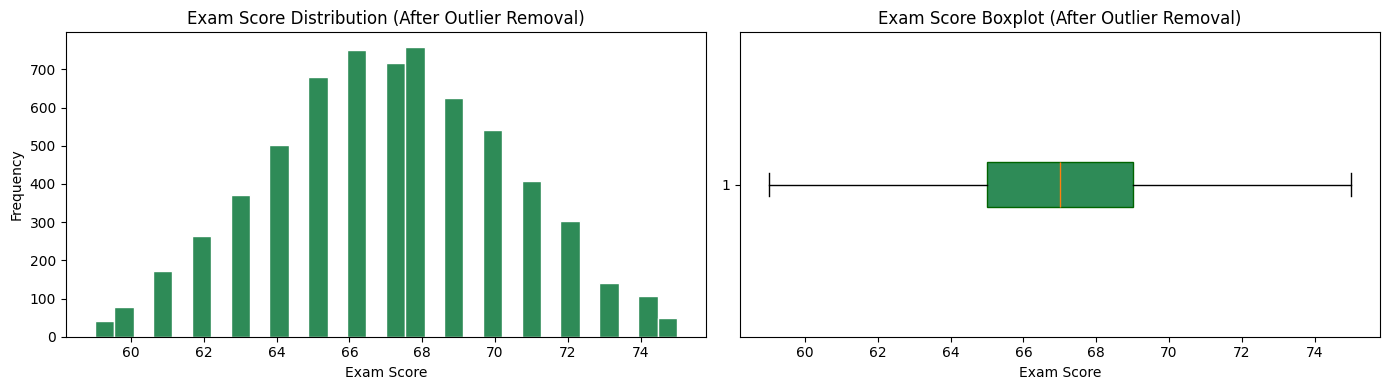

Rows remaining: 6503
count    6503.000000
mean       67.070121
std         3.247506
min        59.000000
25%        65.000000
50%        67.000000
75%        69.000000
max        75.000000
Name: Exam_Score, dtype: float64


In [12]:
# --- Distribution AFTER outlier removal ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["Exam_Score"], bins=30, color="seagreen", edgecolor="white")
axes[0].set_title("Exam Score Distribution (After Outlier Removal)")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df["Exam_Score"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="seagreen", color="darkgreen"))
axes[1].set_title("Exam Score Boxplot (After Outlier Removal)")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

print(f"Rows remaining: {len(df)}")
print(df["Exam_Score"].describe())

## Defining Features and Target

`X` contains all predictor columns; `y` contains only the target `Exam_Score`.
Separating them before the train/test split ensures the target never leaks
into the feature matrix.

In [13]:
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

## Splitting the Data Into Training and Testing Sets 

We reserve **20%** of the data as a held-out test set and use the remaining
**80%** for training. `random_state=439` makes the split reproducible
(matching the course number).

Because `Exam_Score` is continuous (a regression task), stratified splitting
is not applied here - it is designed for classification targets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=439)
# Set random_state for reproducibility, arbitrary choice of 439 to match course number

print(f"Train size: {len(X_train)}")
print(f"Test  size: {len(X_test)}")

Train size: 5202
Test  size: 1301


## Feature Scaling

`StandardScaler` standardises each numeric feature to **mean=0, std=1**.
This is important for models sensitive to feature magnitude such as
Linear Regression and Ridge Regression.

**Key rule:** fit the scaler *only* on the training set, then apply the same
transformation to the test set. Fitting on the full dataset would leak
test-set statistics into training (data leakage).

We wrap the result back into a DataFrame to preserve column names for
easier interpretation in later steps.

In [15]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [16]:
X_train.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Gender_Male
count,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03,5.202000e+03
mean,3.278167e-17,-6.009973e-16,-1.762015e-16,2.704488e-16,-3.756233e-17,-2.219592e-16,4.527968e-16,-1.557129e-16,7.785647e-17,-6.761220e-17,2.356183e-17,2.513262e-16,1.304437e-16,5.600202e-17,7.444171e-17,5.463612e-17,-8.912517e-17,1.085893e-16,2.458625e-17,-2.731806e-18
std,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00
min,-3.218984e+00,-1.739896e+00,-1.558144e+00,-1.568902e+00,-1.215863e+00,-2.062534e+00,-1.729046e+00,-1.299103e+00,-3.537186e+00,-1.213574e+00,-1.056997e+00,-2.003474e+00,-2.876662e+00,-3.424442e-01,-8.948235e-01,-7.512567e-01,-1.510635e+00,-8.006307e-01,-8.126435e-01,-1.179714e+00
25%,-6.702800e-01,-8.698226e-01,-1.227863e-01,-1.398303e-01,-1.215863e+00,-6.972224e-01,-8.282311e-01,-1.299103e+00,2.827106e-01,-4.014020e-01,-1.056997e+00,-3.297833e-01,-9.372640e-01,-3.424442e-01,-8.948235e-01,-7.512567e-01,-1.510635e+00,-8.006307e-01,-8.126435e-01,-1.179714e+00
50%,9.374317e-03,2.508862e-04,-1.227863e-01,-1.398303e-01,8.224610e-01,-1.456648e-02,3.290173e-03,1.372272e-01,2.827106e-01,-4.014020e-01,2.880368e-01,-3.297833e-01,3.243515e-02,-3.424442e-01,-8.948235e-01,-7.512567e-01,6.619732e-01,-8.006307e-01,-8.126435e-01,8.476634e-01
75%,6.890286e-01,8.703244e-01,1.312572e+00,1.289241e+00,8.224610e-01,6.680895e-01,8.348114e-01,1.372272e-01,2.827106e-01,4.107696e-01,2.880368e-01,1.343907e+00,1.002134e+00,-3.424442e-01,3.889249e-01,7.518346e-01,6.619732e-01,1.249015e+00,1.230552e+00,8.476634e-01
max,4.087300e+00,1.740398e+00,1.312572e+00,1.289241e+00,8.224610e-01,2.033401e+00,1.735626e+00,1.573557e+00,2.827106e-01,5.283799e+00,1.633070e+00,1.343907e+00,2.941533e+00,2.920184e+00,1.672673e+00,2.254926e+00,6.619732e-01,1.249015e+00,1.230552e+00,8.476634e-01


---

# Training the Models

We train four regression models and then store them in a dictionary for easy iteration:

- **Linear Regression** - baseline; assumes a linear relationship between features and target
- **Ridge Regression** - linear regression with L2 regularisation to penalise
  large coefficients and reduce overfitting
- **Decision Tree** - non-linear model that recursively partitions the feature space;
  prone to overfitting without depth constraints
- **Random Forest** - ensemble of decision trees that reduces variance by averaging
  predictions across many trees, each trained on a random data/feature subset

## Linear Regression

In [17]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)
lin_reg_y_pred = linear_regression_model.predict(X_test)

print(f"R2 Score: \t{r2_score(y_test, lin_reg_y_pred)}")
print(f"MAE Score: \t{mean_absolute_error(y_test, lin_reg_y_pred)}")
print(f"RMSE score: \t{np.sqrt(mean_squared_error(y_test, lin_reg_y_pred))}")

R2 Score: 	0.9904727287044169
MAE Score: 	0.2661619929995495
RMSE score: 	0.31830519651079714


## Decision Tree

In [18]:
decision_tree_model = DecisionTreeRegressor(random_state=439)
decision_tree_model.fit(X_train, y_train)
dec_tree_y_pred = decision_tree_model.predict(X_test)

print(f"R2 Score: \t{r2_score(y_test, dec_tree_y_pred)}")
print(f"MAE Score: \t{mean_absolute_error(y_test, dec_tree_y_pred)}")
print(f"RMSE score: \t{np.sqrt(mean_squared_error(y_test, dec_tree_y_pred))}")

R2 Score: 	0.7061915188864559
MAE Score: 	1.3735588009223674
RMSE score: 	1.7676310701918134


## Random Forest

In [19]:
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=439)
random_forest_model.fit(X_train, y_train)
rand_for_y_pred = random_forest_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, rand_for_y_pred)}")
print(f"MAE Score: {mean_absolute_error(y_test, rand_for_y_pred)}")
print(f"RMSE score: {np.sqrt(mean_squared_error(y_test, rand_for_y_pred))}")

R2 Score: 0.8932455954713884
MAE Score: 0.8451345119139123
RMSE score: 1.0654973253583924


## Ridge and Lasso Regression

In [20]:
ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(X_train, y_train)
ridge_y_pred = ridge_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, ridge_y_pred)}")
print(f"MAE Score: {mean_absolute_error(y_test, ridge_y_pred)}")
print(f"RMSE score: {np.sqrt(mean_squared_error(y_test, rand_for_y_pred))}")

R2 Score: 0.9904742305765132
MAE Score: 0.26614195371826654
RMSE score: 1.0654973253583924


---

# Evaluation

We assess each model with three complementary metrics:

- **MAE (Mean Absolute Error)** - average absolute difference between predicted
  and actual exam scores; expressed in exam-score points, making it the most
  interpretable metric for this problem
- **RMSE (Root Mean Squared Error)** - like MAE but penalises large errors more
  heavily; useful for detecting models that occasionally make very large mistakes
- **R2 (Coefficient of Determination)** - proportion of variance in `Exam_Score`
  explained by the model; 1.0 = perfect, 0 = no better than always predicting the mean

## Comparing Models Side by Side

In [21]:
models = {
    'Linear Regression': linear_regression_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'Ridge/Lasso': ridge_model
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })
    
pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,MAE,RMSE,R2
3,Ridge/Lasso,0.266142,0.318280,0.990474
0,Linear Regression,0.266162,0.318305,0.990473
2,Random Forest,0.845135,1.065497,0.893246
1,Decision Tree,1.373559,1.767631,0.706192


## Checking for Overfitting

We additionally compare **train vs. test R2** to detect overfitting: a large gap
means the model memorised training data rather than learning generalisable patterns.

In [22]:
for name, model in models.items():
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test,  model.predict(X_test))
    diff = train_r2-test_r2
    print(f"{name}: \tTrain R2={train_r2:.4f}, \tTest R2={test_r2:.4f}, \tDifference={diff:.4f}")

Linear Regression: 	Train R2=0.9897, 	Test R2=0.9905, 	Difference=-0.0007
Decision Tree: 	Train R2=1.0000, 	Test R2=0.7062, 	Difference=0.2938
Random Forest: 	Train R2=0.9844, 	Test R2=0.8932, 	Difference=0.0912
Ridge/Lasso: 	Train R2=0.9897, 	Test R2=0.9905, 	Difference=-0.0007


## Visualizing Predictions

Plotting actual vs predicted scores for the best models - Linear Regression and Ridge.

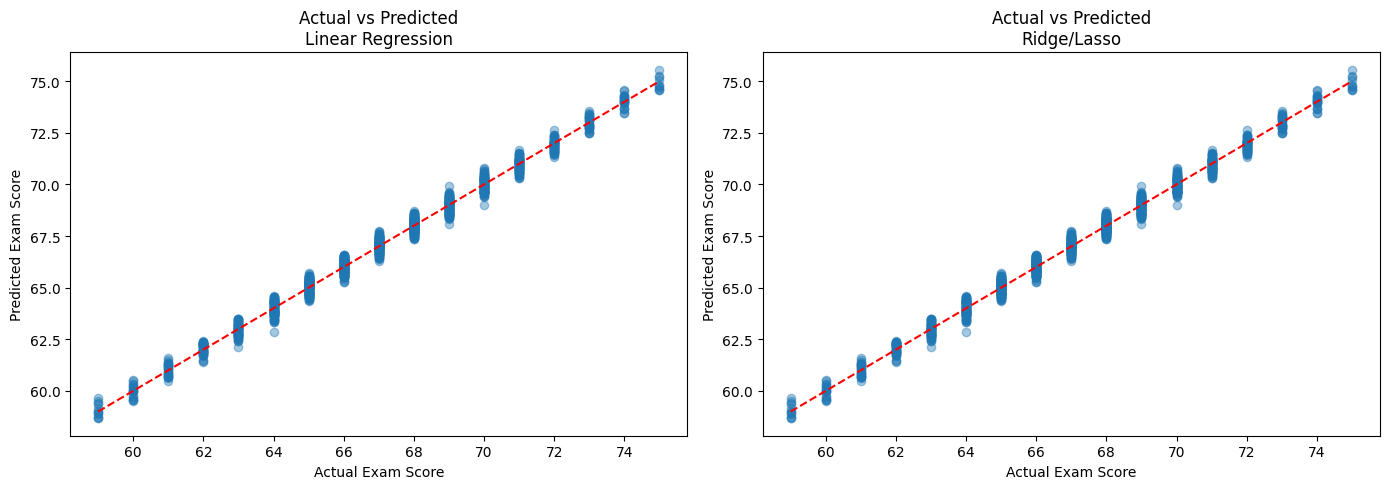

In [23]:
# All four importances side by side
best_models = {
    'Linear Regression': linear_regression_model,
    'Ridge/Lasso': ridge_model
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel("Actual Exam Score")
    ax.set_ylabel("Predicted Exam Score")
    ax.set_title(f"Actual vs Predicted\n{name}")

plt.tight_layout()
plt.show()

## Feature Importance

Both Linear Regression and Ridge are linear models, so importance is measured by the size of the coefficients after scaling. Larger absolute value = stronger influence on `Exam_Score`.

Decision Tree and Random Forest are both tree-based models. This means they expose `.feature_importances_`, which measures how much each feature reduces prediction error across all splits.

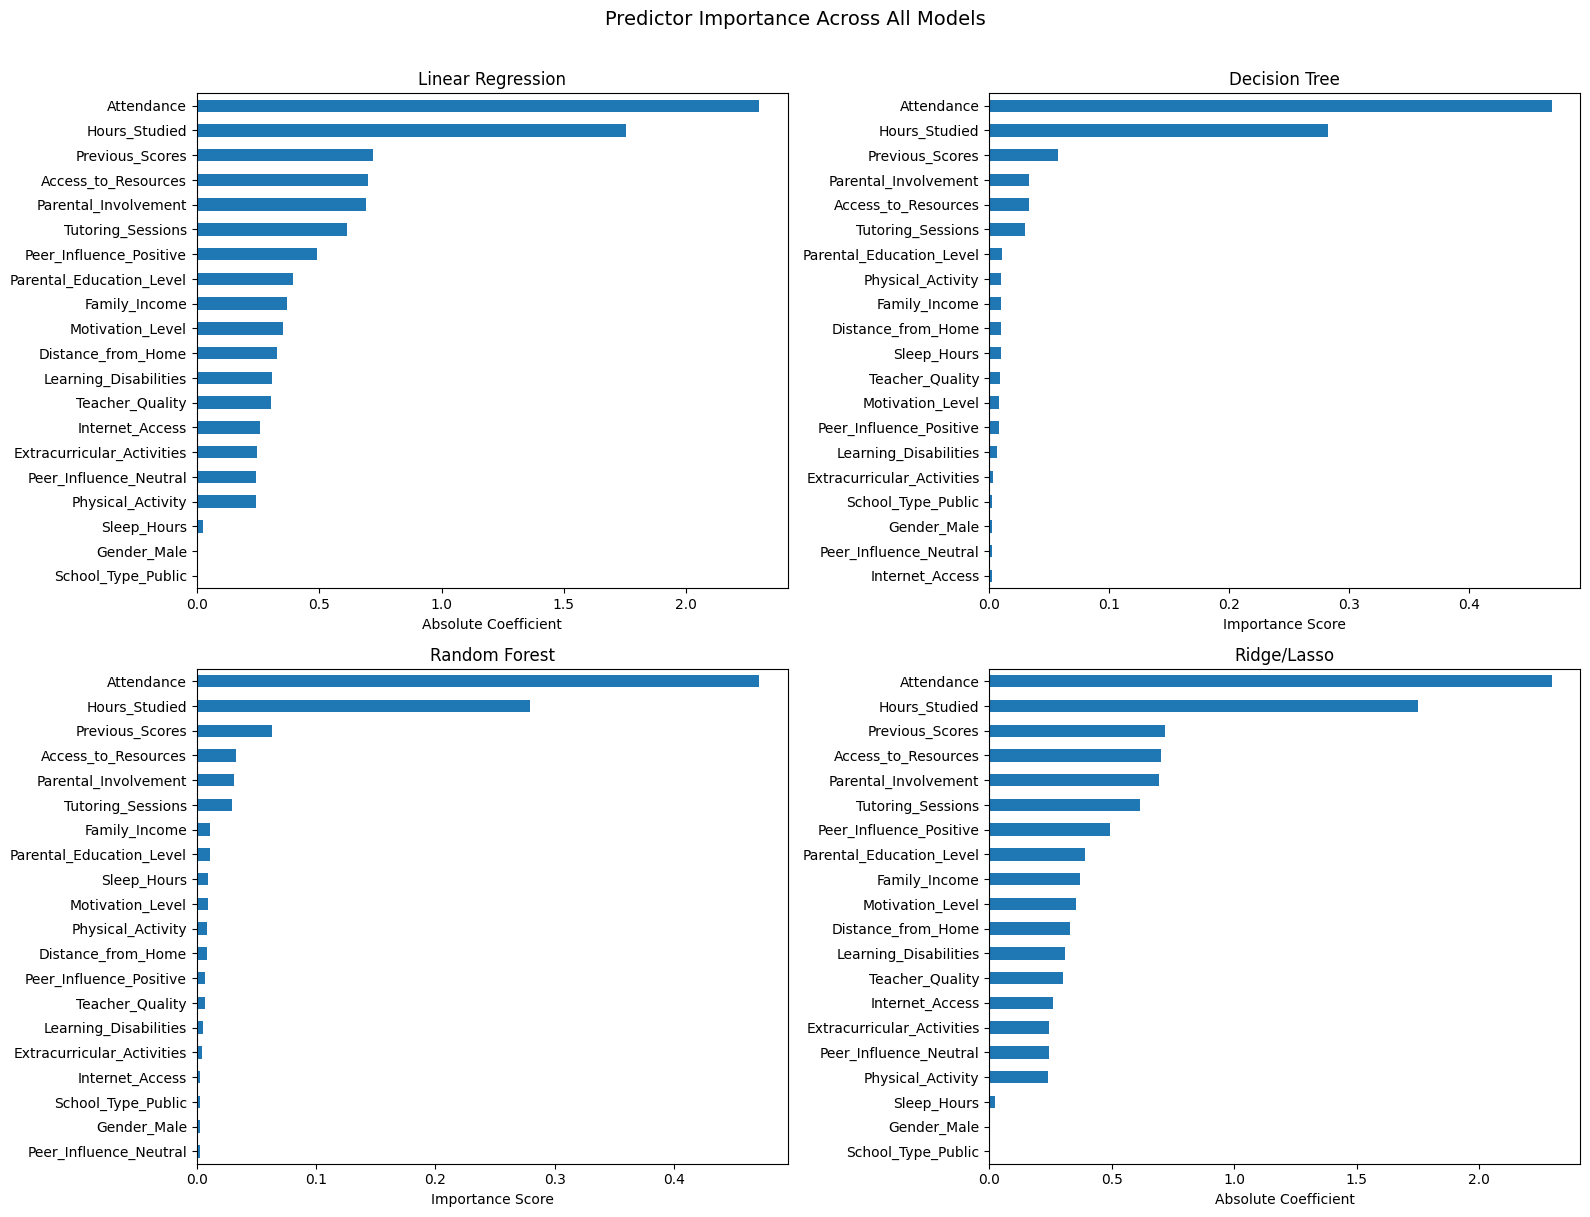

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    if hasattr(model, "coef_"):
        importance = pd.Series(model.coef_, index=X_train.columns).abs()
        xlabel = "Absolute Coefficient"
    else:
        importance = pd.Series(model.feature_importances_, index=X_train.columns)
        xlabel = "Importance Score"

    importance.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(name)
    ax.set_xlabel(xlabel)

plt.suptitle("Predictor Importance Across All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()